# ChromGEM Layer 3 (Monte Carlo) Layer
## Author: Dr. Ruyi Gong
### Description: This Jupyter Notebook contains the code for performing Monte Carlo simulations of fluorophore photokinetics to model the emissions detected by Single Molecule Localization Microscopy (SMLM) in Layer #3 of the Chromatin Geometry Empowered (ChromGEM) pipeline. The inputs into this Notebook are a file containing the positions of the probes labeling the chromatin sample (post-simulated wash) and a file containing the positions of the nucleosomes in the ground truth model chromatin sample. The outputs of this Notebook include the Monte-Carlo modeled localizations emitted from the probes thus detected by the microscope and reformatted input coordinates of the EdU small-molecule label probes, the BrdU antibody label probes, and SREV-generated nucleosomes for downstream analysis.


#### Step 1. Load packages.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import scipy
import pandas as pd
import tifffile as tif #211108 update, the latest skimage does not have external anymore

import seaborn as sns
from astropy import modeling
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from scipy import stats
import time
from sklearn.cluster import DBSCAN
from scipy.spatial import ConvexHull, convex_hull_plot_2d
import seaborn as sns

from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm
import scipy.spatial.distance
from scipy.spatial.distance import cdist

from scipy.stats import lognorm, nbinom
from PIL import Image

#### Step 2. Set plot parameters for figures (e.g., label performance profiles).

In [5]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['xtick.major.size'] = 3
plt.rcParams['xtick.major.width'] = 1
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['legend.edgecolor'] = 'w'

#### Step 3. Load helper function for processing the output from Layer 2 and read in the Layer 2 outputs (the label probe coordinates of the BrdU antibody labeling case, the label probe coordinations of the EdU small-molecule click labeling case, and the coordinates of the nucleosomes in the ground truth SREV model chromosome configuration*).


_*Note: The example ground truth chromatin file given below is named "edited" config because before performing the label diffusivity simulations, the original SREV-generated model chromatin configurations pass through an initial filter In Layer 2 that screens out any nucleosome positions overlapping in a manner unrealistic of the excluded volume occupied by nucleosomes. These screened nucleosome positions were 0-25 out of the outputted 530000+. Label diffusivity simulations are then performed on those "edited" files like the one given below._

In [9]:
def Load_coords(filedir,filename):
    file = open(filedir + '/' + filename,'r')
    atom_symbol, coords = ([] for i in range (2))
    for line in file:
        if len(line.split()) == 4:
            atom,x,y,z = line.split()
            atom_symbol.append(atom)
            coords.append([float(x),float(y),float(z)])
    file.close()
    return np.array(coords)

In [11]:
filedir = ''
filename = 'BrdU-10nm.xyz'
BrdU_coords = Load_coords(filedir,filename)*10

filename = 'BrdU-10nm-washed.xyz'
BrdU_washed_coords = Load_coords(filedir,filename)*10

filedir = ''
filename = 'EdU-2nm.xyz'
EdU_coords = Load_coords(filedir,filename)*10

filename = 'EdU-2nm-washed.xyz'
EdU_washed_coords = Load_coords(filedir,filename)*10

filedir = ''
filename = 'edited-config-3.xyz'
Nucleosome_coords = Load_coords(filedir,filename)*10

#### For exploration: randomly select a subset of label positions pre- and post- the simulated wash to visualize the effect of the wash step on the simulated labeled sample.

In [13]:
z_low = -200
z_high = z_low + 200
x_low = -600
x_high = x_low + 1200
y_low = -600
y_high = y_low + 1200
sampling_Factor = 0.1
EdU_index = np.where((EdU_coords[:,2]>z_low)&(EdU_coords[:,2]<z_high)&(EdU_coords[:,0]>x_low)&(EdU_coords[:,0]<x_high)&(EdU_coords[:,1]>y_low)&(EdU_coords[:,1]<y_high))
EdU_washed_index = np.where((EdU_washed_coords[:,2]>z_low)&(EdU_washed_coords[:,2]<z_high)&(EdU_washed_coords[:,0]>x_low)&(EdU_washed_coords[:,0]<x_high)&(EdU_washed_coords[:,1]>y_low)&(EdU_washed_coords[:,1]<y_high))
BrdU_index = np.where((BrdU_coords[:,2]>z_low) &(BrdU_coords[:,2]<z_high)&(BrdU_coords[:,0]>x_low)&(BrdU_coords[:,0]<x_high)&(BrdU_coords[:,1]>y_low)&(BrdU_coords[:,1]<y_high))
BrdU_washed_index = np.where((BrdU_washed_coords[:,2]>z_low) &(BrdU_washed_coords[:,2]<z_high)&(BrdU_washed_coords[:,0]>x_low)&(BrdU_washed_coords[:,0]<x_high)&(BrdU_washed_coords[:,1]>y_low)&(BrdU_washed_coords[:,1]<y_high))
Nucleosome_index = np.where((Nucleosome_coords[:,2]>z_low)&(Nucleosome_coords[:,2]<z_high)&(Nucleosome_coords[:,0]>x_low)&(Nucleosome_coords[:,0]<x_high)&(Nucleosome_coords[:,1]>y_low)&(Nucleosome_coords[:,1]<y_high))

EdU_index = np.random.choice(EdU_index[0], int(len(EdU_index[0])*sampling_Factor), replace=False)
EdU_washed_index = np.random.choice(EdU_washed_index[0], int(len(EdU_washed_index[0])*sampling_Factor), replace=False)
BrdU_index = np.random.choice(BrdU_index[0], int(len(BrdU_index[0])*sampling_Factor), replace=False)
BrdU_washed_index = np.random.choice(BrdU_washed_index[0], int(len(BrdU_washed_index[0])*sampling_Factor), replace=False)
Nucleosome_index = np.random.choice(Nucleosome_index[0], int(len(Nucleosome_index[0])*sampling_Factor), replace=False)

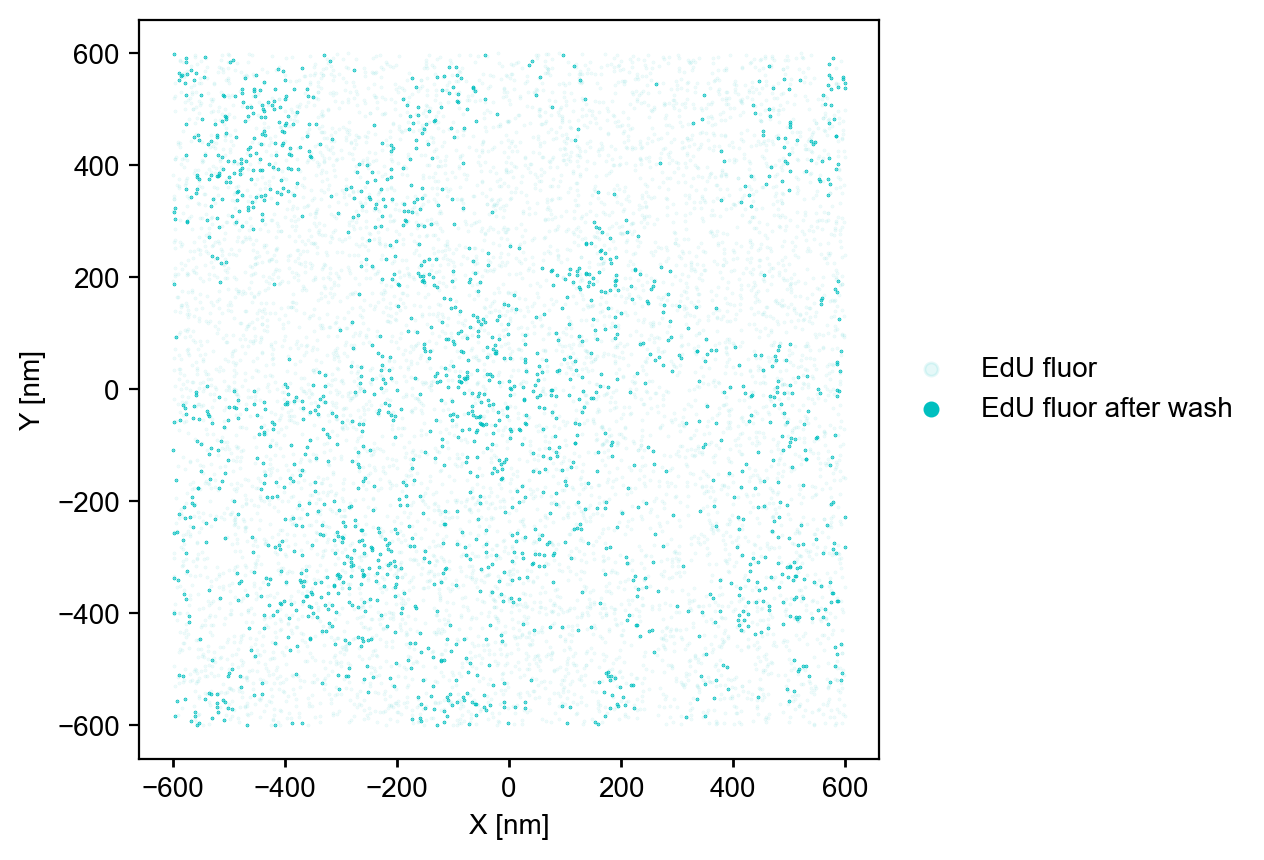

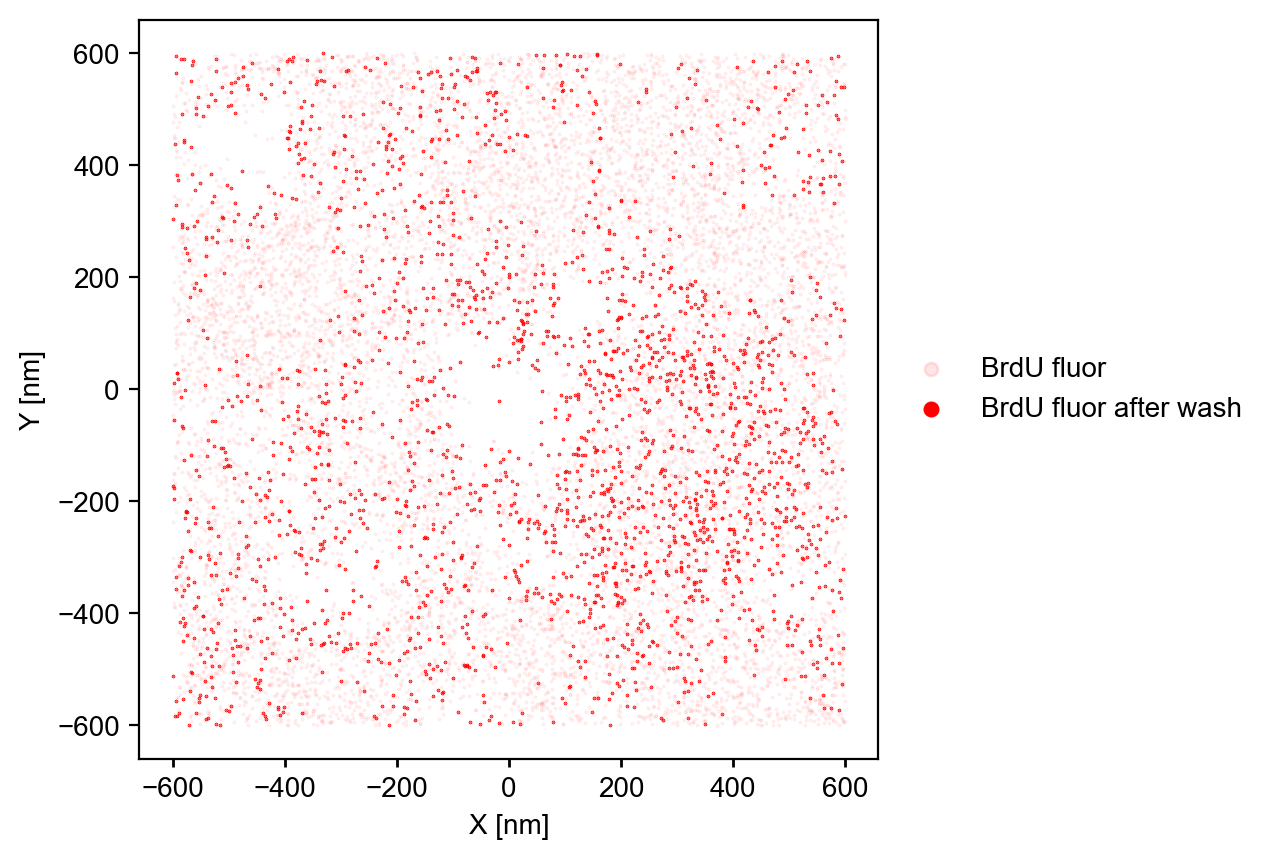

In [16]:
fig = plt.figure()
ax = fig.add_subplot()
ax.scatter(EdU_coords[EdU_index,0], EdU_coords[EdU_index,1],s = 0.1, alpha = 0.1, c = 'c', label='EdU fluor')
# ax.scatter(BrdU_coords[BrdU_index,0], BrdU_coords[BrdU_index,1],s = 0.1, alpha = 0.1, c = 'r', label='BrdU fluor')
ax.scatter(EdU_washed_coords[EdU_washed_index,0], EdU_washed_coords[EdU_washed_index,1],s = 0.1, alpha = 1, c = 'c', label='EdU fluor after wash')
# ax.scatter(Nucleosome_coords[Nucleosome_index,0], Nucleosome_coords[Nucleosome_index,1],s = 0.1, alpha = 0.5, c = 'y', label='Nucleosome')
ax.set_xticks(np.arange(x_low,x_high+1,200))
ax.set_yticks(np.arange(y_low,y_high+1,200))
# ax.set_xticklabels(np.arange(x_low*10,x_high*10,200))
# ax.set_yticklabels(np.arange(y_low*10,y_high*10,200))
ax.set_xlabel('X [nm]')
ax.set_ylabel('Y [nm]')
ax.set_aspect('equal', adjustable='box')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), markerscale=15)
plt.show()

fig = plt.figure()
ax = fig.add_subplot()
# ax.scatter(EdU_coords[EdU_index,0], EdU_coords[EdU_index,1],s = 0.1, alpha = 1, c = 'c', label='EdU fluor')
ax.scatter(BrdU_coords[BrdU_index,0], BrdU_coords[BrdU_index,1],s = 0.1, alpha = 0.1, c = 'r', label='BrdU fluor')
ax.scatter(BrdU_washed_coords[BrdU_washed_index,0], BrdU_washed_coords[BrdU_washed_index,1],s = 0.1, alpha = 1, c = 'r', label='BrdU fluor after wash')
# ax.scatter(Nucleosome_coords[Nucleosome_index,0], Nucleosome_coords[Nucleosome_index,1],s = 0.1, alpha = 0.5, c = 'y', label='Nucleosome')
ax.set_xticks(np.arange(x_low,x_high+1,200))
ax.set_yticks(np.arange(y_low,y_high+1,200))
# ax.set_xticklabels(np.arange(x_low*10,x_high*10,200))
# ax.set_yticklabels(np.arange(y_low*10,y_high*10,200))
ax.set_xlabel('X [nm]')
ax.set_ylabel('Y [nm]')
ax.set_aspect('equal', adjustable='box')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), markerscale=15)
plt.show()

#### Step 5. Perform the Monte Carlo photokinetics simulation in order to generate the localization events emitted from the label probes and detected by the microscope.

Reference: Yeo, W.-H. et al. Investigating uncertainties in single-molecule localization microscopy using experimentally informed Monte Carlo simulation. Nano Lett. 23, 7253–7259 (2023). 

In [69]:
def generateLocalization(coord_array):
    df_localizations = pd.DataFrame(columns=['fluor_x', 'fluor_y', '# localization', 'localization_x','localization_y'])
    for coordinates in coord_array:
        # n_blinks = nbinom.rvs(15,np.exp(-0.5),loc=0,size =1)
        n_blinks = nbinom.rvs(1.6,np.exp(-0.5),loc=0,size =1)
        # n_blinks = nbinom.rvs(7.7,np.exp(-0.5),loc=0,size =1)
        for i in np.arange(n_blinks):
            uncertainty_xy = lognorm.rvs(0.401825, scale = np.exp(2.29608),size=1)
            theta = np.random.uniform(0, 2*np.pi)
            localization_x = coordinates[0] + uncertainty_xy*np.cos(theta)
            localization_y = coordinates[1] + uncertainty_xy*np.sin(theta)
            df_localizations = pd.concat([df_localizations, pd.DataFrame([[coordinates[0], coordinates[1], i+1, localization_x,
                                            localization_y]], columns= df_localizations.columns)], ignore_index=True)
    return df_localizations



df_locali_EdU = generateLocalization(EdU_washed_coords[EdU_washed_index])
df_locali_EdU['localization_x'] = df_locali_EdU['localization_x'].astype(float)
df_locali_EdU['localization_y'] = df_locali_EdU['localization_y'].astype(float)

df_locali_BrdU = generateLocalization(BrdU_washed_coords[BrdU_washed_index])
df_locali_BrdU['localization_x'] = df_locali_BrdU['localization_x'].astype(float)
df_locali_BrdU['localization_y'] = df_locali_BrdU['localization_y'].astype(float)

print(df_locali_EdU)
print(df_locali_BrdU)

C:\Users\rgr9379\AppData\Local\Temp\ipykernel_34180\3884387240.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  for i in np.arange(n_blinks):
C:\Users\rgr9379\AppData\Local\Temp\ipykernel_34180\3884387240.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_localizations = pd.concat([df_localizations, pd.DataFrame([[coordinates[0], coordinates[1], i+1, localization_x,
C:\Users\rgr9379\AppData\Local\Temp\ipykernel_34180\3884387240.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extr

       fluor_x   fluor_y # localization  localization_x  localization_y
0    -177.6400  464.6310              1     -186.290411      459.751410
1    -312.6820 -269.0430              1     -311.471069     -257.524740
2    -179.9010  318.7280              1     -194.965422      316.313749
3    -133.0930  186.9200              1     -126.953013      185.736634
4    -441.2100  302.2550              1     -449.071641      298.218294
...        ...       ...            ...             ...             ...
1699  -38.3182  222.3040              1      -33.861950      229.453893
1700  -38.3182  222.3040              2      -43.570132      231.871225
1701 -422.5270  -57.9291              1     -413.024936      -56.165930
1702 -422.5270  -57.9291              2     -424.374504      -72.747576
1703  410.1990 -402.3270              1      409.388168     -391.863600

[1704 rows x 5 columns]
       fluor_x   fluor_y # localization  localization_x  localization_y
0     486.1470   11.3807              1

In [71]:
save_data_path = ''
df_locali_EdU = df_locali_EdU.rename(columns={'localization_x': 'x [nm]', 'localization_y': 'y [nm]'})
df_locali_EdU.to_csv(save_data_path +'\\df_locali_EdU.csv', index=False)
df_locali_BrdU = df_locali_BrdU.rename(columns={'localization_x': 'x [nm]', 'localization_y': 'y [nm]'})
df_locali_BrdU.to_csv(save_data_path +'\\df_locali_BrdU.csv', index=False)

df_fluor_EdU = pd.DataFrame(data = EdU_washed_coords[EdU_washed_index][:,0:2], columns=['x', 'y'])
df_fluor_EdU = df_fluor_EdU.rename(columns={'x': 'x [nm]', 'y': 'y [nm]'})
df_fluor_EdU.to_csv(save_data_path +'\\df_fluor_EdU.csv', index=False)

df_fluor_BrdU = pd.DataFrame(data = BrdU_washed_coords[BrdU_washed_index][:,0:2], columns=['x', 'y'])
df_fluor_BrdU = df_fluor_BrdU.rename(columns={'x': 'x [nm]', 'y': 'y [nm]'})
df_fluor_BrdU.to_csv(save_data_path +'\\df_fluor_BrdU.csv', index=False)

df_fluor_nucleosome = pd.DataFrame(data = Nucleosome_coords[Nucleosome_index][:,0:2], columns=['x', 'y'])
df_fluor_nucleosome = df_fluor_nucleosome.rename(columns={'x': 'x [nm]', 'y': 'y [nm]'})
df_fluor_nucleosome.to_csv(save_data_path +'\\df_fluor_nucleosome.csv', index=False)